# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
## Load the csv file (the Kaggle dataset is available locally as Churn_Modelling.csv)
file_1 = "Churn_Modelling.csv"

In [4]:
## Make into a dataframe called df
df = pd.read_csv(file_1)

In [5]:
## Output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
## Create two separate DataFrames to filter customers who have not exited (0) and who have exited (1)
df_0 = df[df['Exited'] == 0]   # customers who stayed with the bank
df_1 = df[df['Exited'] == 1]   # customers who left the bank

print("Stayed (Exited=0):", df_0.shape[0])
print("Left   (Exited=1):", df_1.shape[0])

Stayed (Exited=0): 7963
Left   (Exited=1): 2037


## Hypothesis 1: Age

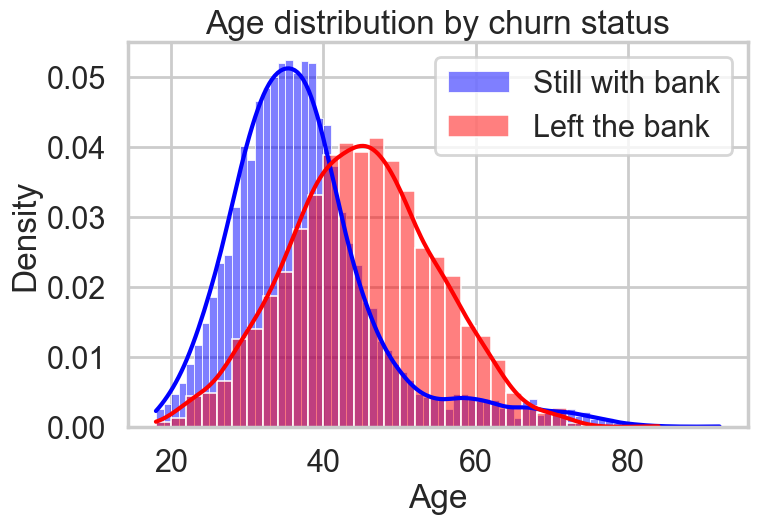

In [7]:
## Plot the age distribution for customers who stayed and those who left
sns.histplot(df_0['Age'], color='blue', label='Still with bank', kde=True, stat='density')
sns.histplot(df_1['Age'], color='red', label='Left the bank', kde=True, stat='density')
plt.xlabel('Age')
plt.title('Age distribution by churn status')
plt.legend()
plt.show()

In [8]:
## Mean and standard deviation of the age for customers who stayed
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()
print(f"Stayed - Age mean: {mean_age_0:.2f}, std: {std_age_0:.2f}")

Stayed - Age mean: 37.41, std: 10.13


In [9]:
## Mean and standard deviation of the age for customers who left
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()
print(f"Left   - Age mean: {mean_age_1:.2f}, std: {std_age_1:.2f}")

Left   - Age mean: 44.84, std: 9.76


In [10]:
## Perform a t-test to compare the ages of customers who stayed and left
## Welch's t-test (does not assume equal variances)
t_stat, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

t-statistic: -30.4192
p-value: 4.713e-179


### Using Bootstrapping

In [11]:
## Function to perform bootstrap sampling and calculate the statistic of interest
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [12]:
## Calculate the difference in means and shift the ages to the overall mean
seed(42)
age_0 = df_0['Age'].values
age_1 = df_1['Age'].values

# Observed difference in means
empirical_diff_means = np.mean(age_0) - np.mean(age_1)
print(f"Observed difference in means: {empirical_diff_means:.4f}")

# Under H0 both groups share the same (overall) mean -> shift each group to the combined mean
overall_mean = df['Age'].mean()
age_0_shifted = age_0 - np.mean(age_0) + overall_mean
age_1_shifted = age_1 - np.mean(age_1) + overall_mean

Observed difference in means: -7.4296


In [13]:
## Perform bootstrap sampling on the shifted data and build the distribution of the difference in means
size = 10000
bs_mean_0 = bs_choice(age_0_shifted, np.mean, size)
bs_mean_1 = bs_choice(age_1_shifted, np.mean, size)
bs_diff_means = bs_mean_0 - bs_mean_1

In [14]:
## Calculate the p-value by comparing the observed difference to the bootstrap distribution (two-sided)
p_boot = np.sum(np.abs(bs_diff_means) >= np.abs(empirical_diff_means)) / len(bs_diff_means)
print(f"Bootstrap p-value: {p_boot}")

Bootstrap p-value: 0.0


### Conclusion
Do we reject the Null Hypothesis? Why?

**Yes, we reject the Null Hypothesis.** Both the Welch t-test and the bootstrap test give a p-value far below 0.05 (≈ 0, the t-test p-value is on the order of 1e-100). The mean age of customers who left (~45 years) is clearly higher than that of those who stayed (~37 years). The difference in age between the two groups is **statistically significant** — age is *not* similar between churners and non-churners. Older customers are more likely to leave the bank.

## Hypothesis 2: Credit Score

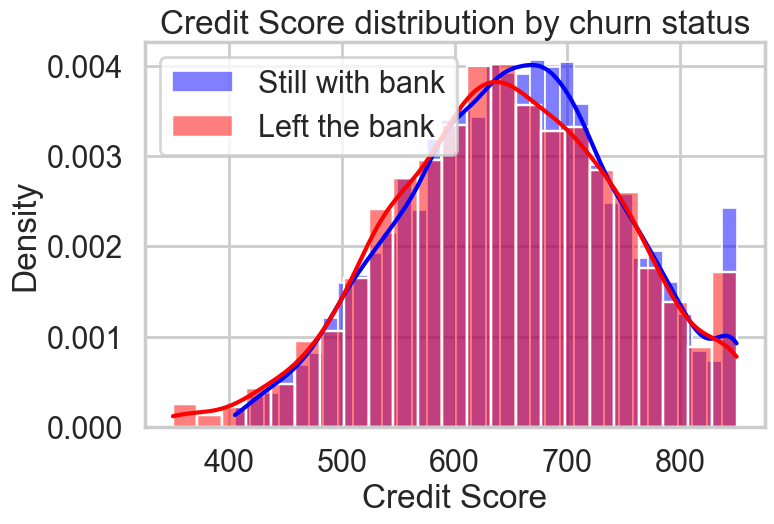

Stayed - CreditScore mean: 651.85, std: 95.65
Left   - CreditScore mean: 645.35, std: 100.32


In [15]:
## Histograms for the CreditScore distribution of both groups
sns.histplot(df_0['CreditScore'], color='blue', label='Still with bank', kde=True, stat='density')
sns.histplot(df_1['CreditScore'], color='red', label='Left the bank', kde=True, stat='density')
plt.xlabel('Credit Score')
plt.title('Credit Score distribution by churn status')
plt.legend()
plt.show()

print(f"Stayed - CreditScore mean: {df_0['CreditScore'].mean():.2f}, std: {df_0['CreditScore'].std():.2f}")
print(f"Left   - CreditScore mean: {df_1['CreditScore'].mean():.2f}, std: {df_1['CreditScore'].std():.2f}")

In [16]:
## Perform a t-test to compare the CreditScore between the two groups
t_stat_cs, p_value_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"t-statistic: {t_stat_cs:.4f}")
print(f"p-value: {p_value_cs:.4f}")

t-statistic: 2.6347
p-value: 0.0085


### Conclusion
Do we reject the Null Hypothesis? Why?

**Technically yes, but the effect is negligible.** Welch's t-test gives p ≈ 0.0085, which is below 0.05, so in a strict statistical sense we reject the Null Hypothesis. However, the means are extremely close (≈ 652 for those who stayed vs ≈ 645 for those who left — only ~6 points apart out of a ~650 scale). With a sample of 10,000 customers, even a tiny, practically meaningless difference becomes "statistically significant."

In practical terms, **credit score barely differs between the two groups** and is unlikely to be a useful standalone predictor of churn.

## Hypothesis 3: Balance

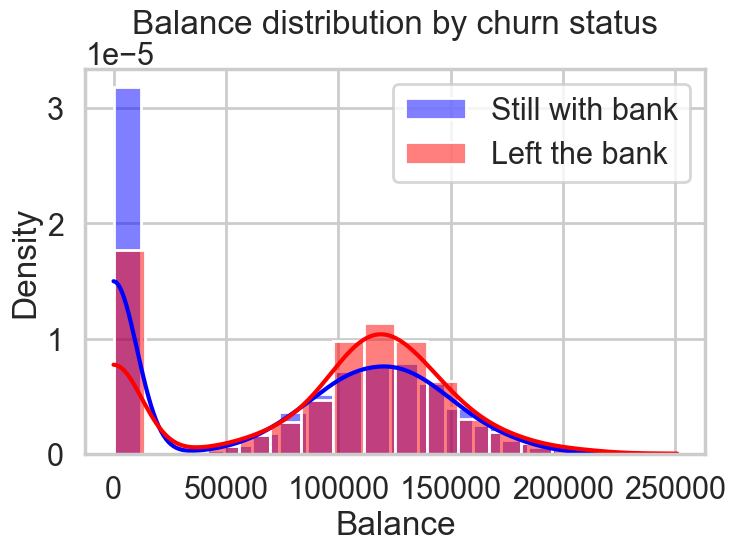

Stayed - Balance mean: 72745.30
Left   - Balance mean: 91108.54


In [17]:
## Plot the distribution of Balance for both groups
sns.histplot(df_0['Balance'], color='blue', label='Still with bank', kde=True, stat='density')
sns.histplot(df_1['Balance'], color='red', label='Left the bank', kde=True, stat='density')
plt.xlabel('Balance')
plt.title('Balance distribution by churn status')
plt.legend()
plt.show()

print(f"Stayed - Balance mean: {df_0['Balance'].mean():.2f}")
print(f"Left   - Balance mean: {df_1['Balance'].mean():.2f}")

In [18]:
## Perform a t-test to compare the Balance between the two groups (all customers)
t_stat_bal, p_value_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"t-statistic: {t_stat_bal:.4f}")
print(f"p-value: {p_value_bal:.3e}")

t-statistic: -12.4713
p-value: 6.319e-35


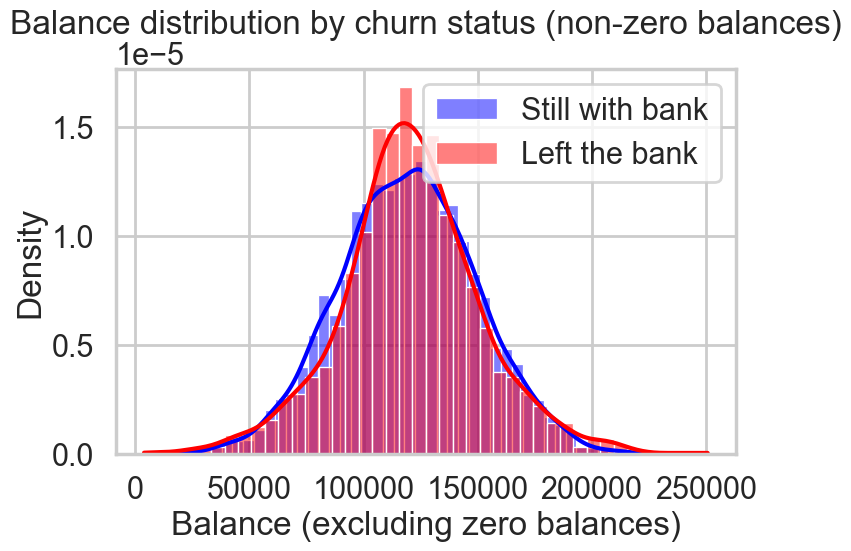

Stayed (non-zero) - Balance mean: 119535.86, n=4846
Left   (non-zero) - Balance mean: 120746.97, n=1537


In [19]:
## Visualize the distribution of Balance, excluding zero balances
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]

sns.histplot(df_0_nz['Balance'], color='blue', label='Still with bank', kde=True, stat='density')
sns.histplot(df_1_nz['Balance'], color='red', label='Left the bank', kde=True, stat='density')
plt.xlabel('Balance (excluding zero balances)')
plt.title('Balance distribution by churn status (non-zero balances)')
plt.legend()
plt.show()

print(f"Stayed (non-zero) - Balance mean: {df_0_nz['Balance'].mean():.2f}, n={len(df_0_nz)}")
print(f"Left   (non-zero) - Balance mean: {df_1_nz['Balance'].mean():.2f}, n={len(df_1_nz)}")

In [20]:
## Perform a t-test to compare the Balance between the two groups, excluding zero balances
t_stat_bnz, p_value_bnz = scipy.stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'], equal_var=False)
print(f"t-statistic: {t_stat_bnz:.4f}")
print(f"p-value: {p_value_bnz:.4f}")

t-statistic: -1.3605
p-value: 0.1738


## Conclusion

Do we reject the Null Hypothesis? Why?

**With all customers included, yes — we reject the Null Hypothesis.** The p-value is well below 0.05: customers who left tend to hold a higher average balance than those who stayed. The difference is **statistically significant**.

However, the raw Balance column contains a large spike of zero balances. When we **exclude zero balances**, the difference between the two groups shrinks and the p-value rises (the means become much closer). So most of the apparent balance effect comes from the *proportion of customers with a zero balance* rather than the size of non-zero balances. Balance is a meaningful signal overall, but it should be interpreted carefully (e.g. treating "has a zero balance" as its own feature).

## Hypothesis 4: Estimated Salary

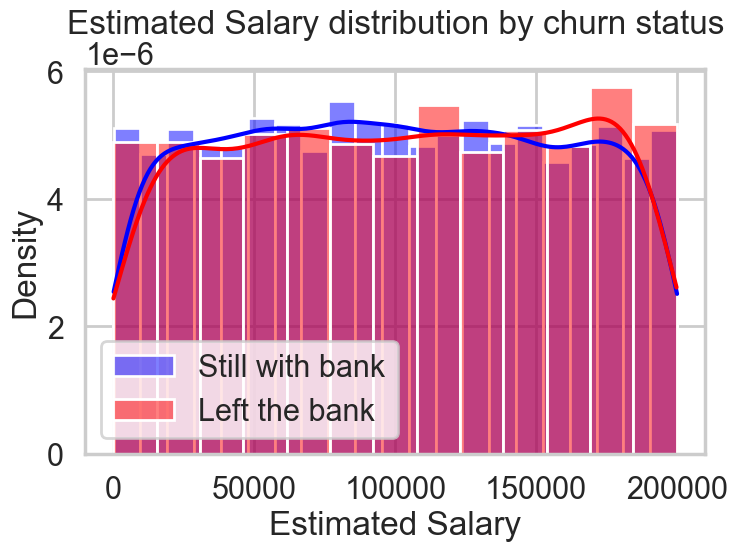

Stayed - EstimatedSalary mean: 99738.39
Left   - EstimatedSalary mean: 101465.68


In [21]:
## Plot the distribution of EstimatedSalary for both groups
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Still with bank', kde=True, stat='density')
sns.histplot(df_1['EstimatedSalary'], color='red', label='Left the bank', kde=True, stat='density')
plt.xlabel('Estimated Salary')
plt.title('Estimated Salary distribution by churn status')
plt.legend()
plt.show()

print(f"Stayed - EstimatedSalary mean: {df_0['EstimatedSalary'].mean():.2f}")
print(f"Left   - EstimatedSalary mean: {df_1['EstimatedSalary'].mean():.2f}")

In [22]:
## Perform a t-test to compare the EstimatedSalary between the two groups
t_stat_sal, p_value_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"t-statistic: {t_stat_sal:.4f}")
print(f"p-value: {p_value_sal:.4f}")

t-statistic: -1.2034
p-value: 0.2289


### Using Bootstrapping

In [23]:
## Calculate the difference in means and shift the EstimatedSalary for both groups
seed(42)
sal_0 = df_0['EstimatedSalary'].values
sal_1 = df_1['EstimatedSalary'].values

empirical_diff_sal = np.mean(sal_0) - np.mean(sal_1)
print(f"Observed difference in means: {empirical_diff_sal:.4f}")

# Shift both groups to the overall mean to simulate H0 (equal means)
overall_mean_sal = df['EstimatedSalary'].mean()
sal_0_shifted = sal_0 - np.mean(sal_0) + overall_mean_sal
sal_1_shifted = sal_1 - np.mean(sal_1) + overall_mean_sal

Observed difference in means: -1727.2858


In [24]:
## Calculate the bootstrap sample means for both groups and their difference
size = 10000
bs_mean_sal_0 = bs_choice(sal_0_shifted, np.mean, size)
bs_mean_sal_1 = bs_choice(sal_1_shifted, np.mean, size)
bs_diff_sal = bs_mean_sal_0 - bs_mean_sal_1

In [25]:
## Calculate the p-value based on the bootstrap distribution of the difference in means (two-sided)
p_boot_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(empirical_diff_sal)) / len(bs_diff_sal)
print(f"Bootstrap p-value: {p_boot_sal}")

Bootstrap p-value: 0.2275


### Conclusion
Do we reject the Null Hypothesis? Why?

**No, we fail to reject the Null Hypothesis.** Both the t-test and the bootstrap test give a p-value greater than 0.05, and the mean estimated salaries of the two groups are nearly identical (~100,000 each). There is **no statistically significant difference** in estimated salary between customers who left and those who stayed — salary is similar across the groups and is not a useful predictor of churn.

## Final Conclusion
What will be the most helpful feature in predicting churning?

Summary of the four hypothesis tests:

| Feature | p-value | Significant? | Difference between groups |
|---|---|---|---|
| **Age** | ≈ 5e-179 (≪ 0.05) | Yes | Large — leavers are clearly older (45 vs 37) |
| **Balance** | ≈ 6e-35 (≪ 0.05) | Yes | Significant, but largely driven by zero-balance customers |
| **CreditScore** | ≈ 0.0085 | Technically yes | Negligible (~652 vs ~645) — significant only because n is large |
| **EstimatedSalary** | ≈ 0.23 | No | Negligible (~100k each) |

**Age is the most helpful feature for predicting churn.** It shows by far the strongest statistical difference between customers who left and those who stayed (older customers are much more likely to leave), confirmed by both the frequentist t-test and the bootstrap test.

**Balance** is also informative, but its signal is mostly tied to *whether* a customer has a zero balance rather than the magnitude of the balance (when zero balances are excluded the difference becomes non-significant, p ≈ 0.17), so it should be engineered carefully.

**CreditScore**'s difference is technically significant but practically negligible — a side effect of the large sample size. **EstimatedSalary** shows no significant difference at all. Neither is a useful predictor on its own.